In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from experiments.plotting import _plot_SRE_distribution, view_correlation
from GNN.training.utils import to_scalar
from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    simulate_circuit,
    training,
)
from src.utils import configure_logger


In [5]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

# Circuits et graphes pour chaque famille

In [6]:
family = "haar"
n_qubits = 14
n_layers = 30
backend = "pennylane"
seed = 1

img, qc, graph_data, gate_count, spec = simulate_circuit(
    family=family,
    n_qubits=n_qubits,
    n_layers=n_layers,
    backend=backend,
    seed=seed,
    regime_type="saturated",
)


2026-06-16 13:46:35,909 - scripts.simulate_circuits - INFO - Simulating circuit family: haar


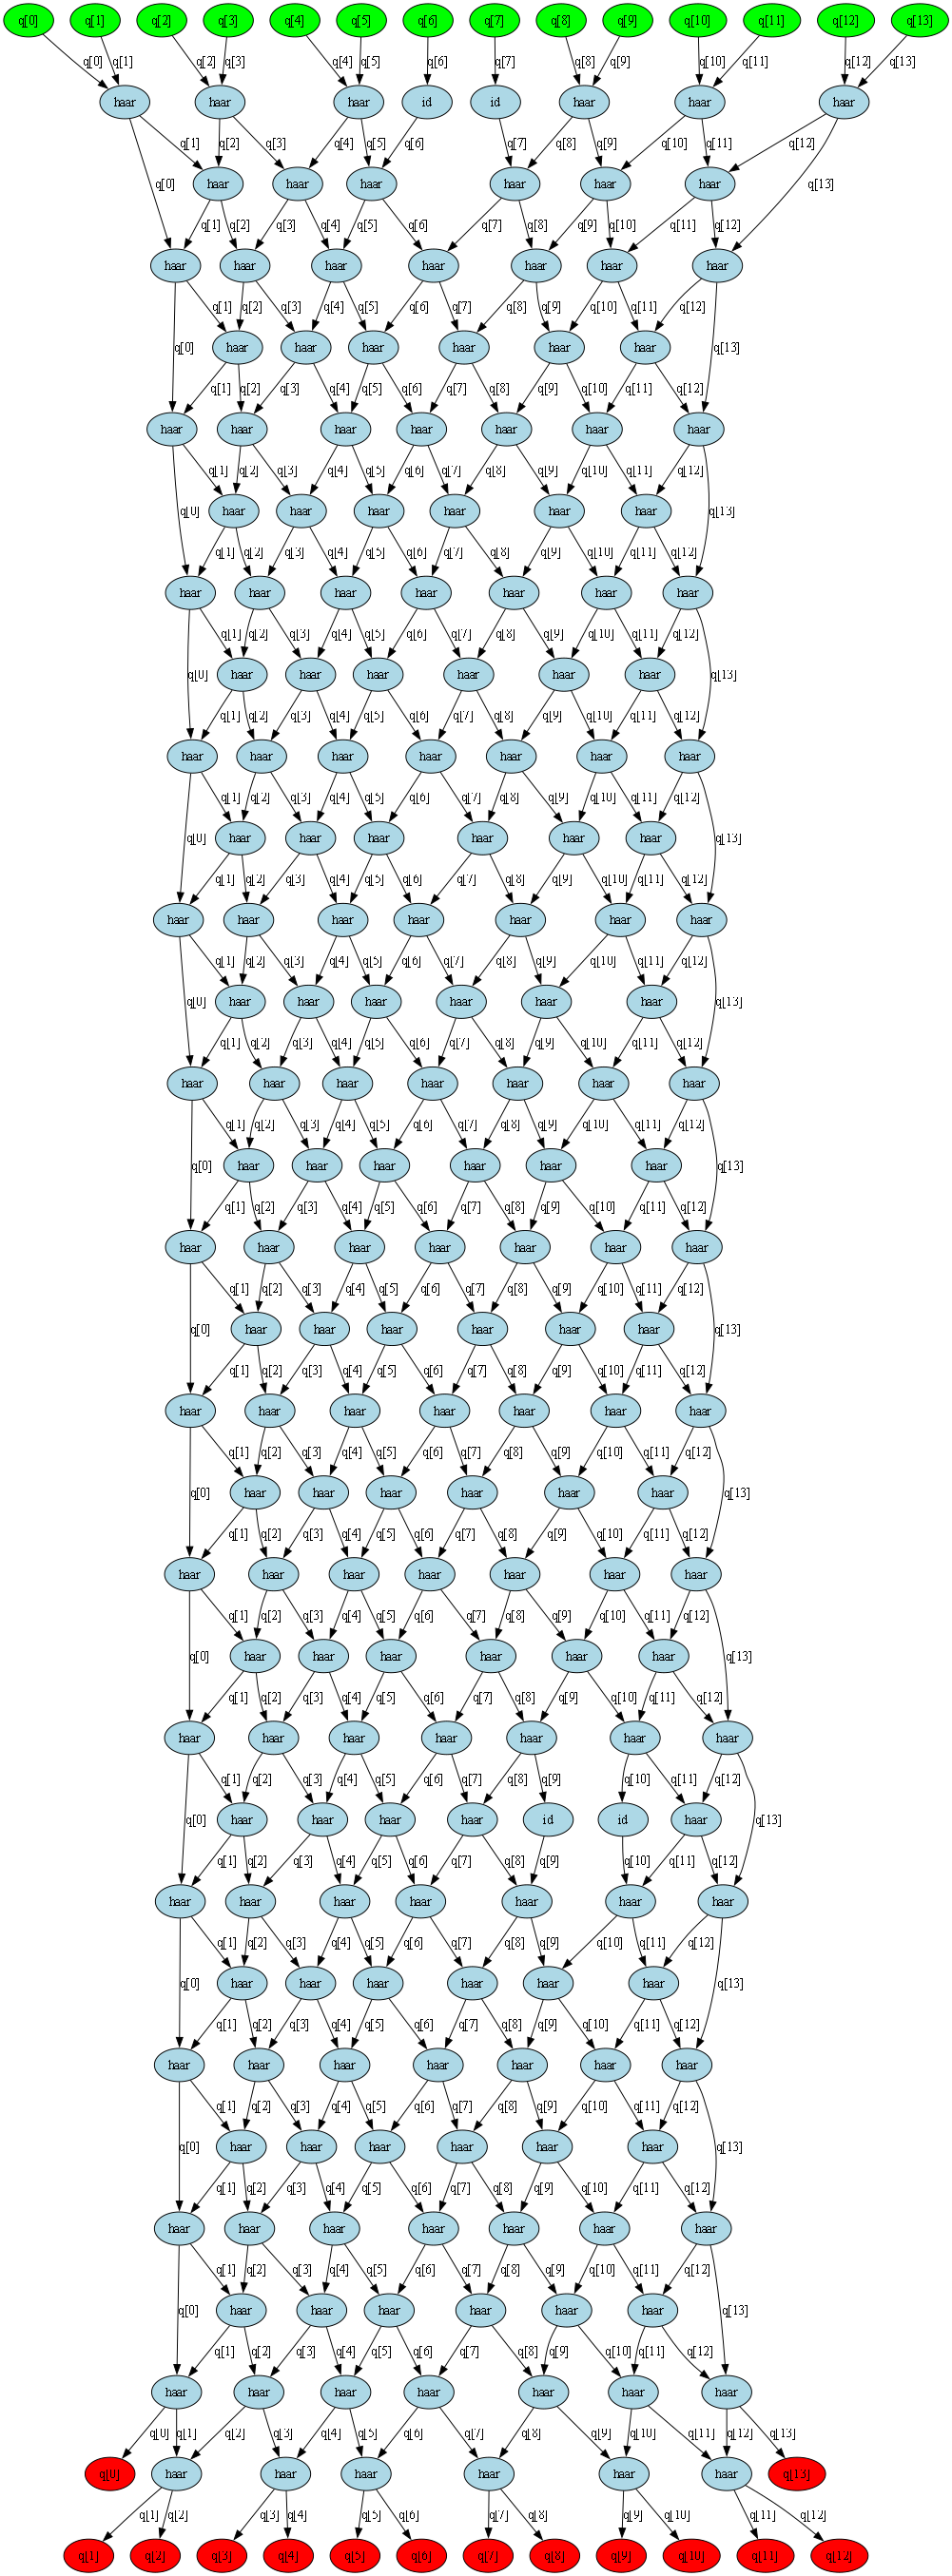

Saved figure to: C:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\qqe\notebooks\final\graph_haar_14q_30l.png


In [7]:
from IPython.display import display, Image as IPyImage
from PIL import Image as PILImage
from io import BytesIO

outdir = Path("final")
outdir.mkdir(parents=True, exist_ok=True)

outfile = outdir / f"graph_{family}_{n_qubits}q_{n_layers}l.png"

try:
    # Case 1: PIL image
    if isinstance(img, PILImage.Image):
        img_to_save = img.convert("RGB") if img.mode == "RGBA" else img
        img_to_save.save(outfile, format="PNG", dpi=(300, 300))
        display(img_to_save)

    # Case 2: Matplotlib figure
    elif hasattr(img, "savefig"):
        img.savefig(outfile, dpi=300, bbox_inches="tight")
        display(img)

    # Case 3: fallback, redraw as matplotlib
    else:
        fig = qc.draw(output="mpl")
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
        display(fig)

    print(f"Saved figure to: {outfile.resolve()}")

except Exception as e:
    print(f"Could not save figure: {e}")

    try:
        bio = BytesIO()
        img.save(bio, format="PNG")
        display(IPyImage(data=bio.getvalue(), format="png"))
    except Exception:
        fig = qc.draw(output="mpl")
        display(fig)

In [8]:
fig = qc.draw(output="mpl", vertical_compression="low", fold=-1)
fig.savefig(f"final/circuit_{family}_{n_qubits}q_{n_layers}l.png", dpi=300, bbox_inches="tight")

# Résultats pour le calcul théorique brute sur 1 seul régime (identity-like et saturé)

In [9]:
from scripts.simulate_circuits import (
    sampling_config_identity_like,
    sampling_config_saturated,
)
from GNN.training.utils import collect_dataset_indices
from GNN.physics_aware_NN import ShardedQuantumCircuitGraphDataset

In [10]:
backend = "pennylane"
target = "SRE"
method = "fwht"
use_dask = True
regime_type = "saturated"
output_dir = f"notebooks/final/data/{regime_type}"
n_bins = 50
families = "haar,clifford"
n_seeds_train = 15
n_seeds_pred = 0
qubit_min, qubit_max = 4, 10
layer_min, layer_max = 2, 150
step = 2
target_qubits = "4,6,8,10"
max_shards = None
dask_workers = 4
dask_memory = "16GiB"

In [11]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=use_dask,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds_train,
    prediction_n_seeds_option=n_seeds_pred,
    qubits_min=qubit_min,
    qubits_max=qubit_max,
    qubits_step=step,
    layers_min=layer_min,
    layers_max=layer_max,
    layers_step=step,
    target_qubits=target_qubits,
    max_shards=max_shards,
    dask_n_workers=dask_workers,
    dask_memory_per_worker=dask_memory,
    block_size=10,
    sampling_config=sampling_config_saturated if regime_type == "saturated" else sampling_config_identity_like,
)

2026-06-16 13:46:53,595 - GNN.dataset_builder - INFO - Processing family: haar
2026-06-16 13:46:53,653 - GNN.dataset_builder - INFO - Generated 32 shards for haar
2026-06-16 13:46:54,692 - parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-06-16 13:46:56,460 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-06-16 13:46:56,521 - distributed.scheduler - INFO - State start
2026-06-16 13:46:56,562 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:50943
2026-06-16 13:46:56,564 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-06-16 13:46:56,565 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-06-16 13:46:56,614 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 16GiB due to system memory limit of 15.64 GiB
2026-06-16 13:46:56,644 - distributed.n

In [39]:
target_variant = "sre"
family = "random"
# regime_type = "identity_like"
regime_type = "saturated"

In [40]:
index_path = collect_dataset_indices(
    f"../notebooks/final/data/{regime_type}",
    family=family,
)
print(f"Collected {len(index_path)} dataset indices for family '{family}' and regime '{regime_type}'")
base_dataset = ShardedQuantumCircuitGraphDataset(
    index_paths=index_path,
    target_variant=target_variant,
    split="all",
    cache_size=64,
)

Collected 1 dataset indices for family 'random' and regime 'saturated'


In [41]:
base_dataset

ShardedQuantumCircuitGraphDataset(4560)

In [42]:
def dataset_to_dataframe(dataset):
    data = []
    keep_fields = ["n_qubits", "n_layers", "sre", "seed", "family"]
    for item in dataset:
        row = {}
        for field in keep_fields:
            if not hasattr(item, field):
                continue

            value = getattr(item, field)
            if field == "family":
                # Keep categorical label as text (e.g., "clifford")
                row[field] = str(value)
            else:
                row[field] = to_scalar(value)
        data.append(row)

    df = pd.DataFrame(data)

    int_cols = ["n_qubits", "n_layers", "seed"]
    for col in int_cols:
        if col in df.columns:
            df[col] = df[col].astype(int)

    float_cols = ["sre"]
    for col in float_cols:
        if col in df.columns:
            df[col] = df[col].astype(float)

    if "family" in df.columns:
        df["family"] = df["family"].astype(str)

    return df

In [43]:
import pandas as pd

df = dataset_to_dataframe(base_dataset)

In [44]:
df

,n_qubits,n_layers,sre,seed,family
0,4,20,2.371908,73412284,random
1,4,20,2.281437,326058550,random
2,4,20,1.948092,468816522,random
3,4,20,2.157287,469965247,random
4,4,20,1.843589,603142375,random
...,...,...,...,...,...
4555,10,138,8.004228,3653462455,random
4556,10,138,8.010819,3799995866,random
4557,10,138,8.001186,3805051427,random
4558,10,138,8.009645,3906685442,random


In [45]:
plot_df = df[
    (df["sre"].notna())
]

In [46]:
plot_df

,n_qubits,n_layers,sre,seed,family
0,4,20,2.371908,73412284,random
1,4,20,2.281437,326058550,random
2,4,20,1.948092,468816522,random
3,4,20,2.157287,469965247,random
4,4,20,1.843589,603142375,random
...,...,...,...,...,...
4555,10,138,8.004228,3653462455,random
4556,10,138,8.010819,3799995866,random
4557,10,138,8.001186,3805051427,random
4558,10,138,8.009645,3906685442,random


In [47]:
avg_df = (
    plot_df
    .groupby(["n_qubits", "n_layers", "family"])
    .agg(
        sre_mean=("sre", "mean"),
        sre_std=("sre", "std"),
    )
    .reset_index()
)

In [48]:
avg_df.to_csv(f"final/data/avg_sre_{family}.csv", index=False)

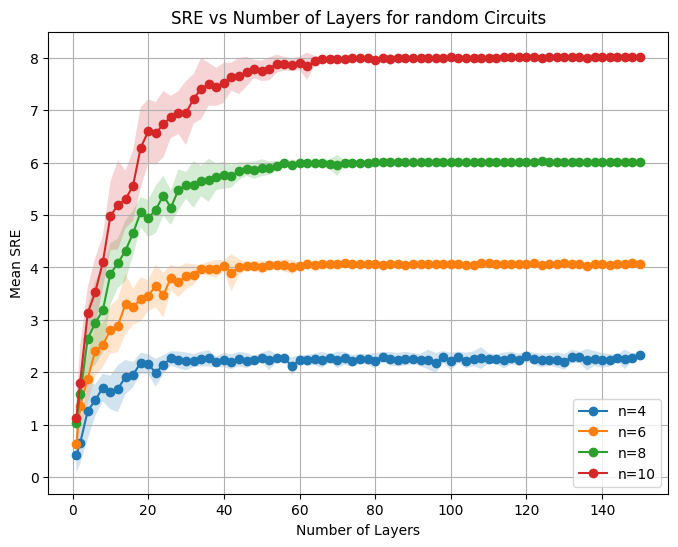

In [49]:
plt.figure(figsize=(8, 6))
for n in sorted(avg_df["n_qubits"].unique()):
    sub = avg_df[avg_df["n_qubits"] == n]

    plt.plot(
        sub["n_layers"],
        sub["sre_mean"],
        marker="o",
        linestyle="-",
        label=f"n={n}",
    )
    plt.fill_between(
        sub["n_layers"],
        sub["sre_mean"] - sub["sre_std"],
        sub["sre_mean"] + sub["sre_std"],
        alpha=0.2,
    )
plt.title(f"SRE vs Number of Layers for {family} Circuits")
plt.xlabel("Number of Layers")
plt.ylabel("Mean SRE")
plt.legend()
plt.grid()
plt.savefig(f"../notebooks/final/figures/SRE/sre_vs_layers_{family}.png", dpi=300, bbox_inches="tight")
plt.show()

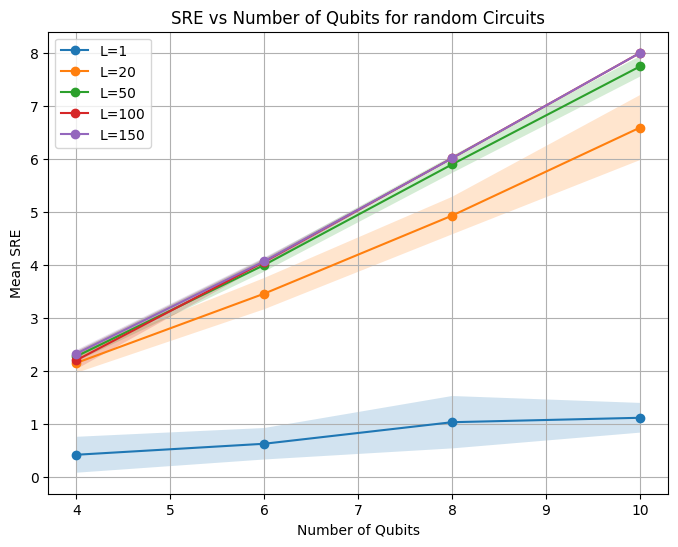

In [50]:
plt.figure(figsize=(8, 6))
chosen_layers = [1, 20, 50, 100, 150]
for L in chosen_layers:
    sub = avg_df[avg_df["n_layers"] == L]
    plt.plot(
        sub["n_qubits"],
        sub["sre_mean"],
        marker="o",
        linestyle="-",
        label=f"L={L}",
    )
    plt.fill_between(
        sub["n_qubits"],
        sub["sre_mean"] - sub["sre_std"],
        sub["sre_mean"] + sub["sre_std"],
        alpha=0.2,
    )
plt.title(f"SRE vs Number of Qubits for {family} Circuits")
plt.xlabel("Number of Qubits")
plt.ylabel("Mean SRE")
plt.legend()
plt.grid()
plt.savefig(f"../notebooks/final/figures/SRE/sre_vs_qubits_{family}.png", dpi=300, bbox_inches="tight")
plt.show()

### Calcul du SRE pour n=12 qubits

In [8]:
from __future__ import annotations

import contextlib
import ctypes
import dataclasses
import gc
import hashlib
import itertools
import json
import logging
import os

from dataclasses import dataclass
from collections import defaultdict
from pathlib import Path
from typing import TYPE_CHECKING, Any, cast

import numpy as np
import torch
from torch_geometric.data import Data, InMemoryDataset

from tqdm import tqdm

from backend import PennylaneBackend, QuimbBackend
from circuit.families import (
    CliffordBrickwork,
    HaarBrickwork,
    QuansistorBrickwork,
    RandomCircuit,
)

# Keep this import path only if it is the correct one in your project.
# If your real function lives in circuit.matrix_factory, switch it there.
from circuit.gates import gate_unitary
from circuit.patterns import TdopingRules, to_qasm
from experiments.core import run_experiment
from GNN.encoder import eigenvalue_phase_histogram_features, qasm_to_pyg_graph
from utils import FileCache

from experiments.core import ExperimentConfig
from properties.compute import PropertyRequest
from states.types import BackendConfig

if TYPE_CHECKING:
    from circuit.spec import GateSpec


BACKEND_REGISTRY = {
    "pennylane": PennylaneBackend,
    "quimb": QuimbBackend,
}

FAMILY_REGISTRY = {
    "haar": HaarBrickwork,
    "clifford": CliffordBrickwork,
    "quansistor": QuansistorBrickwork,
    "random": RandomCircuit,
}

In [33]:
family = "random"
n_qubits = 12
n_layers = 60
backend = "pennylane"
seed = np.random.randint(0, 10000)

img, qc, graph_data, gate_count, spec = simulate_circuit(
    family=family,
    n_qubits=n_qubits,
    n_layers=n_layers,
    backend=backend,
    seed=seed,
    regime_type="saturated", # identity_like, saturated
)

2026-06-12 10:42:04,258 - scripts.simulate_circuits - INFO - Simulating circuit family: random


In [34]:
method = "fwht"
representation = "dense"
cache = FileCache(project_root / "outputs" / "cache")
property_requests = []
property_requests.append(PropertyRequest(name="SRE", method=method, params={}))

backend_config = BackendConfig(
    name=backend,
    representation=representation,
    params={},
)

exp_config = ExperimentConfig(
    spec=spec,
    backend=backend_config,
    properties=property_requests,
)

result = run_experiment(
    exp_config,
    backend_registry=BACKEND_REGISTRY,
    cache=cache,
)

In [35]:
result.results

{'SRE:fwht': PropertyResult(name='SRE', value=np.float64(9.955925598672426), error=None, meta={'method': 'FWHT', 'n_qubits': 12, 'compute_time': 18.7737398147583})}

In [36]:
sre_key = f"SRE:{method.lower()}"
sre = result.results.get(sre_key, None)
print(f"SRE: {float(sre.value) if sre is not None else 'N/A'}")

SRE: 9.955925598672426


In [37]:
result = {
    "family": family,
    "n_qubits": n_qubits,
    "n_layers": n_layers,
    "method": method,
    "seed": seed,
    sre_key: float(sre.value) if sre is not None else None,
}

In [38]:
output_file = Path("final/results.json")

# Load existing results
if output_file.exists():
    with open(output_file, "r") as f:
        results = json.load(f)
else:
    results = []

results.sort(
    key = lambda x: (x["family"], x["n_qubits"], x["n_layers"]),
)
# Add new result
results.append(result)

# Save updated list
with open(output_file, "w") as f:
    json.dump(results, f, indent=4)

# Prédictions

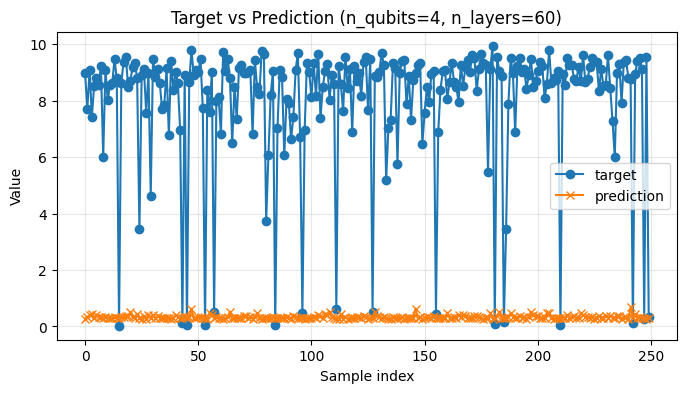

Pearson r = 0.1950


Text(0.5, 1.0, 'True vs Predicted SRE for Haar Family (GNN Model)')

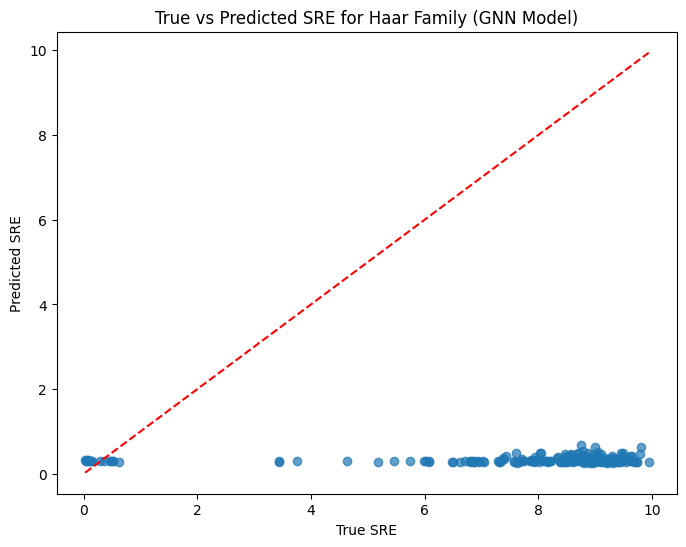

In [53]:
df = pd.read_csv(f"final/predictions/gnn_predictions_quansistor.csv")
plot_qubits = 4
plot_layers = 60
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

nq=plot_qubits
nl=plot_layers
# df["prediction"] = df["prediction"] * nq
view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target_SRE",
    col_y="predicted_SRE",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target_SRE"], df["predicted_SRE"], alpha=0.7)
plt.plot([df["target_SRE"].min(), df["target_SRE"].max()], [df["target_SRE"].min(), df["target_SRE"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Haar Family (GNN Model)")